In [1]:
import numpy as np
import mitsuba as mi
import matplotlib as mpl
import matplotlib.pyplot as plt

import sionna

from sionna.rt import load_scene, Camera, Transmitter, Receiver, PlanarArray,\
                      PathSolver, RadioMapSolver, load_mesh, watt_to_dbm, transform_mesh,\
                      cpx_abs_square

jit_find_library(): Unable to load "/lib/libLLVM.so": /lib/libLLVM.so: cannot open shared object file: No such file or directory!
jitc_llvm_init(): LLVM API initialization failed ..


In [2]:
rm_solver = RadioMapSolver()

In [3]:
z = 30  # fixed height

def config_scene(num_rows, num_cols):
    """Load and configure a scene"""
    scene = load_scene(sionna.rt.scene.etoile)
    scene.bandwidth = 100e6

    # Configure antenna arrays for all transmitters and receivers
    scene.tx_array = PlanarArray(
        num_rows=num_rows,
        num_cols=num_cols,
        pattern="tr38901",
        polarization="V"
    )

    scene.rx_array = PlanarArray(
        num_rows=1,
        num_cols=1,
        pattern="iso",
        polarization="V"
    )

    # ---- Generate 100 transmitter positions ----
    num_tx = 100
    spacing = 20  # meters between transmitters (adjust)
    grid_size = int(np.ceil(np.sqrt(num_tx)))

    positions = []
    look_ats = []

    for i in range(num_tx):
        row = i // grid_size
        col = i % grid_size

        x = -200 + col * spacing
        y = -200 + row * spacing

        positions.append([x,     y,     z])
        look_ats.append([0, 0, 0])   # all look toward center

    positions = np.array(positions)
    look_ats = np.array(look_ats)

    # Fixed power for all TX
    power_dbms = [23] * num_tx

    # Add all transmitters to scene
    for i in range(num_tx):
        scene.add(
            Transmitter(
                name=f"tx{i}",
                position=positions[i],
                look_at=look_ats[i],
                power_dbm=power_dbms[i]
            )
        )

    return scene

In [4]:
# Load and configure scene
num_rows=8
num_cols=2
scene = config_scene(num_rows, num_cols)

# Compute the SINR map
rm = rm_solver(scene,
               max_depth=5,
               samples_per_tx=10**7,
               cell_size=(1, 1))

In [5]:
scene.preview(radio_map=rm, rm_metric="path_gain")

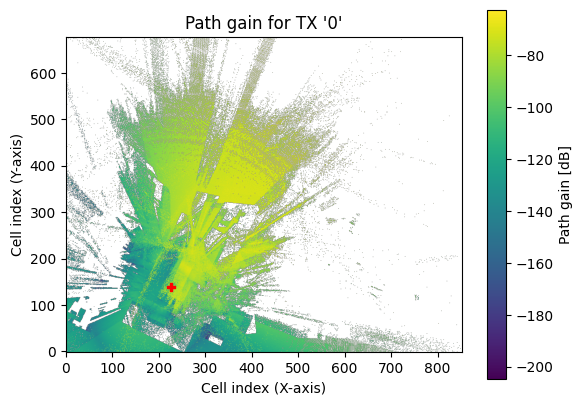

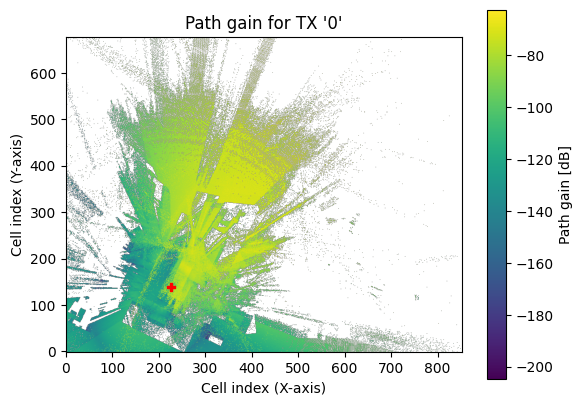

In [6]:
rm.show(metric="path_gain", tx=0)

In [7]:
rm.tx_cell_indices # returns X / Y

[[226, 138],
 [246, 138],
 [266, 138],
 .. 94 skipped ..,
 [366, 318],
 [386, 318],
 [406, 318]]

In [8]:
rm.cell_centers[138][226] # expects Y / X

[-200.331, -199.56, 1.5]

In [9]:
rm.path_gain.shape

(100, 677, 854)

In [10]:
nTx = 5
x = rm.path_gain[nTx][138][246]
dB = 10*np.log10(x)

print(f"{x=}, {dB=}")

x=2.27698e-14, dB=-136.42640113830566


In [11]:
# Save the radio map (dB) into a npy
path_gain_db = 10*np.log10(rm.path_gain)
for i in range(path_gain_db.shape[0]):
    filename = f"transmitters/tx_{i}.bin"
    path_gain_db[i].tofile(filename)  # salva cada bloco em binário

coordinates = []
for y in range(rm.tx_cell_indices.shape[1]):
    base = rm.cell_centers[rm.tx_cell_indices[0][y]][rm.tx_cell_indices[1][y]]
    print(base)
    extra1 = rm.tx_cell_indices[0][y]
    extra2 = rm.tx_cell_indices[1][y]
    coordinates.append([*base, extra1, extra2])
    
# Salvar em arquivo de texto
with open("transmitters/coordinates.txt", "w") as f:
    for c in coordinates:
        f.write(f"{c[1]},{c[0]},{z},{c[4]},{c[3]}\n") # Saving in the format (x, y) -> indexes

/tmp/ipykernel_3946491/822968666.py:2: RuntimeWarning: divide by zero encountered in log10
  path_gain_db = 10*np.log10(rm.path_gain)


[-288.331, -111.56, 1.5]
[-288.331, -91.5603, 1.5]
[-288.331, -71.5603, 1.5]
[-288.331, -51.5603, 1.5]
[-288.331, -31.5603, 1.5]
[-288.331, -11.5603, 1.5]
[-288.331, 8.43973, 1.5]
[-288.331, 28.4397, 1.5]
[-288.331, 48.4397, 1.5]
[-288.331, 68.4397, 1.5]
[-268.331, -111.56, 1.5]
[-268.331, -91.5603, 1.5]
[-268.331, -71.5603, 1.5]
[-268.331, -51.5603, 1.5]
[-268.331, -31.5603, 1.5]
[-268.331, -11.5603, 1.5]
[-268.331, 8.43973, 1.5]
[-268.331, 28.4397, 1.5]
[-268.331, 48.4397, 1.5]
[-268.331, 68.4397, 1.5]
[-248.331, -111.56, 1.5]
[-248.331, -91.5603, 1.5]
[-248.331, -71.5603, 1.5]
[-248.331, -51.5603, 1.5]
[-248.331, -31.5603, 1.5]
[-248.331, -11.5603, 1.5]
[-248.331, 8.43973, 1.5]
[-248.331, 28.4397, 1.5]
[-248.331, 48.4397, 1.5]
[-248.331, 68.4397, 1.5]
[-228.331, -111.56, 1.5]
[-228.331, -91.5603, 1.5]
[-228.331, -71.5603, 1.5]
[-228.331, -51.5603, 1.5]
[-228.331, -31.5603, 1.5]
[-228.331, -11.5603, 1.5]
[-228.331, 8.43973, 1.5]
[-228.331, 28.4397, 1.5]
[-228.331, 48.4397, 1.5]
[-228

In [12]:
path_gain_db[0][10][20]

-121.59996

In [ ]:
## Optimize the gateway position based on rm.path_gain
import numpy as np
from pyomo.environ import *

# Defining the numpy seed
np.random.seed(0)

# Transmission powers available
T = [10, 20, 30] # dBm ?

# SF parameter
Sfs = [7, 8, 9, 10, 11, 12]

# Positions grid
P = [
    (-288.331, -111.56, 1.5),
    (-288.331, -91.5603, 1.5),
    (-288.331, -71.5603, 1.5),
    (-288.331, -51.5603, 1.5),
    (-288.331, -31.5603, 1.5),
    (-288.331, -11.5603, 1.5),
    (-288.331, 8.43973, 1.5),
    (-288.331, 28.4397, 1.5),
    (-288.331, 48.4397, 1.5),
    (-288.331, 68.4397, 1.5),

    (-268.331, -111.56, 1.5),
    (-268.331, -91.5603, 1.5),
    (-268.331, -71.5603, 1.5),
    (-268.331, -51.5603, 1.5),
    (-268.331, -31.5603, 1.5),
    (-268.331, -11.5603, 1.5),
    (-268.331, 8.43973, 1.5),
    (-268.331, 28.4397, 1.5),
    (-268.331, 48.4397, 1.5),
    (-268.331, 68.4397, 1.5),

    (-248.331, -111.56, 1.5),
    (-248.331, -91.5603, 1.5),
    (-248.331, -71.5603, 1.5),
    (-248.331, -51.5603, 1.5),
    (-248.331, -31.5603, 1.5),
    (-248.331, -11.5603, 1.5),
    (-248.331, 8.43973, 1.5),
    (-248.331, 28.4397, 1.5),
    (-248.331, 48.4397, 1.5),
    (-248.331, 68.4397, 1.5),

    (-228.331, -111.56, 1.5),
    (-228.331, -91.5603, 1.5),
    (-228.331, -71.5603, 1.5),
    (-228.331, -51.5603, 1.5),
    (-228.331, -31.5603, 1.5),
    (-228.331, -11.5603, 1.5),
    (-228.331, 8.43973, 1.5),
    (-228.331, 28.4397, 1.5),
    (-228.331, 48.4397, 1.5),
    (-228.331, 68.4397, 1.5),

    (-208.331, -111.56, 1.5),
    (-208.331, -91.5603, 1.5),
    (-208.331, -71.5603, 1.5),
    (-208.331, -51.5603, 1.5),
    (-208.331, -31.5603, 1.5),
    (-208.331, -11.5603, 1.5),
    (-208.331, 8.43973, 1.5),
    (-208.331, 28.4397, 1.5),
    (-208.331, 48.4397, 1.5),
    (-208.331, 68.4397, 1.5),

    (-188.331, -111.56, 1.5),
    (-188.331, -91.5603, 1.5),
    (-188.331, -71.5603, 1.5),
    (-188.331, -51.5603, 1.5),
    (-188.331, -31.5603, 1.5),
    (-188.331, -11.5603, 1.5), 
    (-188.331, 8.43973, 1.5),
    (-188.331, 28.4397, 1.5),
    (-188.331, 48.4397, 1.5),
    (-188.331, 68.4397, 1.5),

    (-168.331, -111.56, 1.5),
    (-168.331, -91.5603, 1.5),
    (-168.331, -71.5603, 1.5),
    (-168.331, -51.5603, 1.5),
    (-168.331, -31.5603, 1.5),
    (-168.331, -11.5603, 1.5),
    (-168.331, 8.43973, 1.5),
    (-168.331, 28.4397, 1.5),
    (-168.331, 48.4397, 1.5),
    (-168.331, 68.4397, 1.5),

    (-148.331, -111.56, 1.5),
    (-148.331, -91.5603, 1.5),
    (-148.331, -71.5603, 1.5),
    (-148.331, -51.5603, 1.5),
    (-148.331, -31.5603, 1.5),
    (-148.331, -11.5603, 1.5),
    (-148.331, 8.43973, 1.5),
    (-148.331, 28.4397, 1.5),
    (-148.331, 48.4397, 1.5),
    (-148.331, 68.4397, 1.5),

    (-128.331, -111.56, 1.5),
    (-128.331, -91.5603, 1.5),
    (-128.331, -71.5603, 1.5),
    (-128.331, -51.5603, 1.5),
    (-128.331, -31.5603, 1.5),
    (-128.331, -11.5603, 1.5),
    (-128.331, 8.43973, 1.5),
    (-128.331, 28.4397, 1.5),
    (-128.331, 48.4397, 1.5),
    (-128.331, 68.4397, 1.5),

    (-108.331, -111.56, 1.5),
    (-108.331, -91.5603, 1.5),
    (-108.331, -71.5603, 1.5),
    (-108.331, -51.5603, 1.5),
    (-108.331, -31.5603, 1.5),
    (-108.331, -11.5603, 1.5),
    (-108.331, 8.43973, 1.5),
    (-108.331, 28.4397, 1.5),
    (-108.331, 48.4397, 1.5),
    (-108.331, 68.4397, 1.5),
]

# Creating the model
model = ConcreteModel()

# Set of positions
N = len(P)
model.P = RangeSet(0, N-1)

# PDR TEST
pdr_list = np.random.randint(0, 100, N)

# PDR dict
pdr_dict = {i: pdr_list[i] for i in range(N)}

# Models parameters
model.pdr = Param(model.P, initialize=pdr_dict)

# Declaring the decision variables
model.x = Var(model.P, domain=Binary) # -> 1 if the position is chosen, 0 if not

# Constraints -> choose the best position for the gateway lorawan that:
# Firstly => only 1 position for the gateway placement
# Define some power threshold for all end-devices
# Take into account the energy of the devices (end or gateways ?)

# Only 1 gateway (beginning)
def one_gateway_rule(m):
    return sum(m.x[i] for i in m.P) == 1

model.one_gateway = Constraint(rule=one_gateway_rule)

# Objective: maximize the PDR
def objective_rule(m):
    return sum(m.pdr[i] * m.x[i] for i in m.P)

model.obj = Objective(rule=objective_rule, sense=maximize)

model.pprint()

# Power threshold, PDR, X(Binary) ----------------- SF, Energy, TP - Future steps
# One gateway (X) -> Power constraint (min) (To decide) ->  MAX = One gateway per position

1 RangeSet Declarations
    P : Dimen=1, Size=100, Bounds=(0, 99)
        Key  : Finite : Members
        None :   True :  [0:99]

1 Param Declarations
    pdr : Size=100, Index=P, Domain=Any, Default=None, Mutable=False
        Key : Value
          0 :    44
          1 :    47
          2 :    64
          3 :    67
          4 :    67
          5 :     9
          6 :    83
          7 :    21
          8 :    36
          9 :    87
         10 :    70
         11 :    88
         12 :    88
         13 :    12
         14 :    58
         15 :    65
         16 :    39
         17 :    87
         18 :    46
         19 :    88
         20 :    81
         21 :    37
         22 :    25
         23 :    77
         24 :    72
         25 :     9
         26 :    20
         27 :    80
         28 :    69
         29 :    79
         30 :    47
         31 :    64
         32 :    82
         33 :    99
         34 :    88
         35 :    49
         36 :    29
         37 :    19

In [33]:
# Solver part
solver = SolverFactory("glpk")
result = solver.solve(model)

# Pegando a posição escolhida
best_index = [i for i in model.P if value(model.x[i]) > 0.5][0]
best_position = P[best_index]
best_pdr = pdr_list[best_index]

print("Melhor índice:", best_index)
print("Melhor posição:", best_position)
print("Score nessa posição:", best_pdr)

Melhor índice: 33
Melhor posição: (-228.331, -51.5603, 1.5)
Score nessa posição: 99


In [36]:
result

{'Problem': [{'Name': 'unknown', 'Lower bound': 99.0, 'Upper bound': 99.0, 'Number of objectives': 1, 'Number of constraints': 1, 'Number of variables': 100, 'Number of nonzeros': 100, 'Sense': 'maximize'}], 'Solver': [{'Status': 'ok', 'Termination condition': 'optimal', 'Statistics': {'Branch and bound': {'Number of bounded subproblems': '1', 'Number of created subproblems': '1'}}, 'Error rc': 0, 'Time': 0.004393577575683594}], 'Solution': [OrderedDict([('number of solutions', 0), ('number of solutions displayed', 0)])]}

In [26]:
np.max(pdr_list)
pdr_list

array([44, 47, 64, 67, 67,  9, 83, 21, 36, 87, 70, 88, 88, 12, 58, 65, 39,
       87, 46, 88, 81, 37, 25, 77, 72,  9, 20, 80, 69, 79, 47, 64, 82, 99,
       88, 49, 29, 19, 19, 14, 39, 32, 65,  9, 57, 32, 31, 74, 23, 35, 75,
       55, 28, 34,  0,  0, 36, 53,  5, 38, 17, 79,  4, 42, 58, 31,  1, 65,
       41, 57, 35, 11, 46, 82, 91,  0, 14, 99, 53, 12, 42, 84, 75, 68,  6,
       68, 47,  3, 76, 52, 78, 15, 20, 99, 58, 23, 79, 13, 85, 48])